## Name: Aryan Mahesh Patil
### Rollno: 46
#### Subject: DL
#### Experiment No: 9

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [9]:
df=pd.read_csv("/content/usd-inr-exchange-rate - usd-inr-exchange-rate.csv")

df.head()

,date,usd_inr
0,1973-01-02,8.02
1,1973-01-03,8.02
2,1973-01-04,8.00
3,1973-01-05,8.01
4,1973-01-08,8.00


,date,usd_inr
0,1973-01-02,8.02
1,1973-01-03,8.02
2,1973-01-04,8.00
3,1973-01-05,8.01
4,1973-01-08,8.00


In [10]:
df.tail()

,date,usd_inr
13429,2026-08-03,95.91
13430,2026-08-04,95.38
13431,2026-08-05,95.14
13432,2026-08-06,95.21
13433,2026-08-07,95.21


,date,usd_inr
13429,2026-08-03,95.91
13430,2026-08-04,95.38
13431,2026-08-05,95.14
13432,2026-08-06,95.21
13433,2026-08-07,95.21


In [11]:
#=============Split=============
data=df["usd_inr"].values.reshape(-1,1)

split=int(0.8*len(data))

train_raw=data[:split]
test_raw=data[split:]

print(train_raw.shape)
print(test_raw.shape)
#===========Normalize===========
scaler=MinMaxScaler()
train_data=scaler.fit_transform(train_raw)
test_data=scaler.transform(test_raw)

(10747, 1)
(2687, 1)
(10747, 1)
(2687, 1)


In [12]:
seq_len=30
X_train=[]
y_train=[]

for i in range(len(train_data)-seq_len):
  X_train.append(train_data[i:i+seq_len])
  y_train.append(train_data[i+seq_len])
X_test=[]
y_test=[]

for i in range(len(test_data)-seq_len):
  X_test.append(test_data[i:i+seq_len])
  y_test.append(test_data[i+seq_len])

X_train=torch.tensor(np.array(X_train),dtype=torch.float32)
y_train=torch.tensor(np.array(y_train),dtype=torch.float32)
X_test=torch.tensor(np.array(X_test),dtype=torch.float32)
y_test=torch.tensor(np.array(y_test),dtype=torch.float32)

In [13]:
class LSTMModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.lstm=nn.LSTM(
        input_size=1,
        hidden_size=64,
        num_layers=1,
        batch_first=True
        )
    self.fc=nn.Linear(64,1)

  def forward(self,x):
    _, (h,_)=self.lstm(x)
    return self.fc(h[-1])

In [14]:
model=LSTMModel()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [15]:
epochs=100
for epoch in range(epochs):
  model.train()
  output=model(X_train)
  loss=criterion(output,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch+1)%20==0:
    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 20, Loss: 0.0556899756193161
Epoch: 40, Loss: 0.019794950261712074
Epoch: 60, Loss: 0.005281966179609299
Epoch: 80, Loss: 0.0008273973362520337
Epoch: 100, Loss: 0.00031659536762163043


Test RMSE= 10.0594


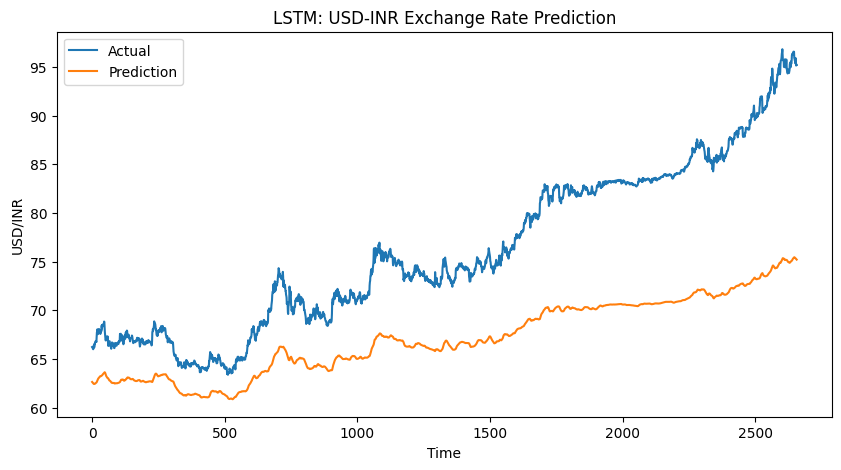

In [16]:
model.eval()
with torch.no_grad():
  prediction =model(X_test).numpy()

  actual=scaler.inverse_transform(y_test.numpy())
  prediction=scaler.inverse_transform(prediction)

  rmse=np.sqrt(mean_squared_error(actual,prediction))
  print(f"Test RMSE=",round(rmse,4))

plt.figure(figsize=(10,5))
plt.plot(actual,label="Actual")
plt.plot(prediction,label="Prediction")
plt.xlabel("Time")
plt.ylabel("USD/INR")
plt.title("LSTM: USD-INR Exchange Rate Prediction")
plt.legend()
plt.show()